librerias

In [1]:
#Data
import pandas as pd

#Plots
import matplotlib.pyplot as plt

#fits
from scipy.optimize import curve_fit

#math
import numpy as np
import scipy.integrate as integrate


#Constants
from scipy.constants import physical_constants
m_u=physical_constants['atomic mass constant energy equivalent in MeV'][0]
from scipy.constants import speed_of_light as c
#from scipy.constants import Boltzmann as kb
#from scipy.constants import Stefan_Boltzmann as Sb

#Usefull
from tqdm.notebook import tqdm
import os
from scipy.interpolate import interp1d
import pynucastro as pyna
#%matplotlib widget

carga de datos

In [2]:
'''our model
#data_con_teo=pd.read_csv('Results/epsilon_dot_in_theoretical_500.csv')
#data_sin_teo_sin_Ir194=pd.read_csv('Results/epsilon_dot_sin_theoretical_sin_Ir194.csv')
#data_sin_teo_sin_Ac225_Pt197=pd.read_csv('Results/epsilon_dot_sin_theoretical_sin_Ac225_Pt197.csv')

data_sin_teo=pd.read_csv('Results/acltual_I/epsilon_dot_out_theoretical_500.csv')
data_sin_teo_exp=pd.read_csv('Results/epsilon_dot_out_theoretical_exp.csv')

time_days=data_sin_teo['time_days']
time=time_days*86400 #convertir a segundos

Epsilon_alpha_in=data_con_teo['epsilon_dot_alpha']
Epsilon_beta_in=data_con_teo['epsilon_dot_beta_minus']      
Epsilon_dot_in=data_con_teo['epsilon_dot']


Epsilon_alpha_out=data_sin_teo['epsilon_dot_alpha']
Epsilon_beta_out=data_sin_teo['epsilon_dot_beta_minus']
Epsilon_dot_out=data_sin_teo['epsilon_dot']

Epsilon_alpha_out_exp=data_sin_teo_exp['epsilon_dot_alpha']
Epsilon_beta_out_exp=data_sin_teo_exp['epsilon_dot_beta_minus'] 
Epsilon_dot_out_exp=data_sin_teo_exp['epsilon_dot']

Epsilon_alpha_out_sin_Ir194=data_sin_teo_sin_Ir194['epsilon_dot_alpha']
Epsilon_beta_out_sin_Ir194=data_sin_teo_sin_Ir194['epsilon_dot_beta_minus']
Epsilon_dot_out_sin_Ir194=data_sin_teo_sin_Ir194['epsilon_dot']

Epsilon_alpha_out_sin_Ac225_Pt197=data_sin_teo_sin_Ac225_Pt197['epsilon_dot_alpha']
Epsilon_beta_out_sin_Ac225_Pt197=data_sin_teo_sin_Ac225_Pt197['epsilon_dot_beta_minus']
Epsilon_dot_out_sin_Ac225_Pt197=data_sin_teo_sin_Ac225_Pt197['epsilon_dot']

usefull data
data_usefull=pd.read_csv('Results/Usefull/out/Xa.csv')
Xa_out=data_usefull['Xa']
data_usefull2=pd.read_csv('Results/Usefull/in/Xa.csv')
Xa=data_usefull2['Xa']
'''

"our model\n#data_con_teo=pd.read_csv('Results/epsilon_dot_in_theoretical_500.csv')\n#data_sin_teo_sin_Ir194=pd.read_csv('Results/epsilon_dot_sin_theoretical_sin_Ir194.csv')\n#data_sin_teo_sin_Ac225_Pt197=pd.read_csv('Results/epsilon_dot_sin_theoretical_sin_Ac225_Pt197.csv')\n\ndata_sin_teo=pd.read_csv('Results/acltual_I/epsilon_dot_out_theoretical_500.csv')\ndata_sin_teo_exp=pd.read_csv('Results/epsilon_dot_out_theoretical_exp.csv')\n\ntime_days=data_sin_teo['time_days']\ntime=time_days*86400 #convertir a segundos\n\nEpsilon_alpha_in=data_con_teo['epsilon_dot_alpha']\nEpsilon_beta_in=data_con_teo['epsilon_dot_beta_minus']      \nEpsilon_dot_in=data_con_teo['epsilon_dot']\n\n\nEpsilon_alpha_out=data_sin_teo['epsilon_dot_alpha']\nEpsilon_beta_out=data_sin_teo['epsilon_dot_beta_minus']\nEpsilon_dot_out=data_sin_teo['epsilon_dot']\n\nEpsilon_alpha_out_exp=data_sin_teo_exp['epsilon_dot_alpha']\nEpsilon_beta_out_exp=data_sin_teo_exp['epsilon_dot_beta_minus'] \nEpsilon_dot_out_exp=data_sin_t

In [2]:
e_b_i=pd.read_csv('Results/actual_I/beta/epsilon_beta.csv')['Epsilon_beta']
e_a_i=pd.read_csv('Results/actual_I/alpha/epsilon_alpha.csv')['Epsilon_alpha']
e_b_ii=pd.read_csv('Results/actual_II/beta/epsilon_Beta.csv')['Epsilon_beta']
e_a_ii=pd.read_csv('Results/actual_II/alpha/epsilon_alpha.csv')['Epsilon_alpha']
time_days=pd.read_csv('Results/actual_I/beta/epsilon_beta.csv')['Time [Days]']

Xa=pd.read_csv('Results/Usefull/out/Xa.csv')['Xa']
time=time_days*24*60*60

In [3]:
''' Other Models for Heating Rate'''

#important parameters
Mey=0.05
Vey=0.15#c

#termalization Barnes 2016
a_th=0.27
b_th=0.1
d_th=0.6
e_th=0.36*(np.exp(-a_th*time_days)+np.log(1+2*b_th*time_days**d_th)/(2*b_th*time_days**d_th))

#termalization beta
ty=0.3*np.sqrt(Mey/0.01)*(0.2/Vey)##termalization gamma particles
f_gamma=1-np.exp(-(ty/time_days)**2)

#termalization Metzger 2010
e_Metzger_th=0.75


#Metzger 2010
E_metzger=e_Metzger_th*(3*10**10)*(time_days)**(-1.3)

#aproximation
E_korobkin=e_th*(4*10**18)*(0.5-(1/np.pi)*np.arctan((time_days*24*60*60-1.3)/0.11))**(1.3)

#Power Law Hotokezaka
E_hoto_e=(4*10**9)*(time_days)**(-1.3)
E_hoto_g=(8*10**9)*(time_days)**(-1.3)
E_hoto_a=(7*10**8)*(1/time_days)*(Xa/3e-2)
E_hoto_f=(2*10**9)*(1/time_days)*(Xa/2e-2)
E_Hoto=E_hoto_e+f_gamma*E_hoto_g+E_hoto_a+E_hoto_f

#power law Waxman 2018
e_wax=2E10
beta_wax=1.3
alpha_wax=3
kappa_wax=0.2
M_wax=0.05
v_wax=0.1
t_M=1.5*(1/np.sqrt(1+2*alpha_wax))*np.sqrt((kappa_wax)*(M_wax/0.01)*(0.1/v_wax))
E_waxman=e_wax*(time_days/t_M)**(-beta_wax)

#termalization for waxman
f_vy=0.7
kappa_e=1
t_e=15*(1/np.sqrt(alpha_wax*(2+3*alpha_wax)))*np.sqrt(kappa_e*M_wax/0.01)*(0.1/v_wax)**(3/2)
f_e=(t_e/time_days)**2<1
f_e=np.zeros(len(time_days))+1-1*f_e+f_e*(t_e/time_days)**2
E_waxman_efectivo=(1-f_vy)*E_waxman*f_e

#XKN model
E_xkn=0.5*(10**10)*(time_days)**(-1.3)+2e10*np.exp(-time_days/1)

#termalizations ours
tb=12.9*((Mey/0.01)**(2/3))*((Vey/0.2)**(-2))*24*60*60 #termalization beta particles
ty=0.3*np.sqrt(Mey/0.01)*(0.2/Vey)*24*60*60 ##termalization gamma particles
f_gamma=1-np.exp(-(ty/time)**2)
f_electrons=(1+time/tb)**(-1)
f_beta=0.2*f_electrons+0.45*f_gamma
f_alpha=(1+time/(3*tb))**(-1)

e_b_i_ef=e_b_i*f_beta
e_b_ii_ef=e_b_ii*f_beta
e_a_i_ef=e_a_i*f_alpha
e_a_ii_ef=e_a_ii*f_alpha


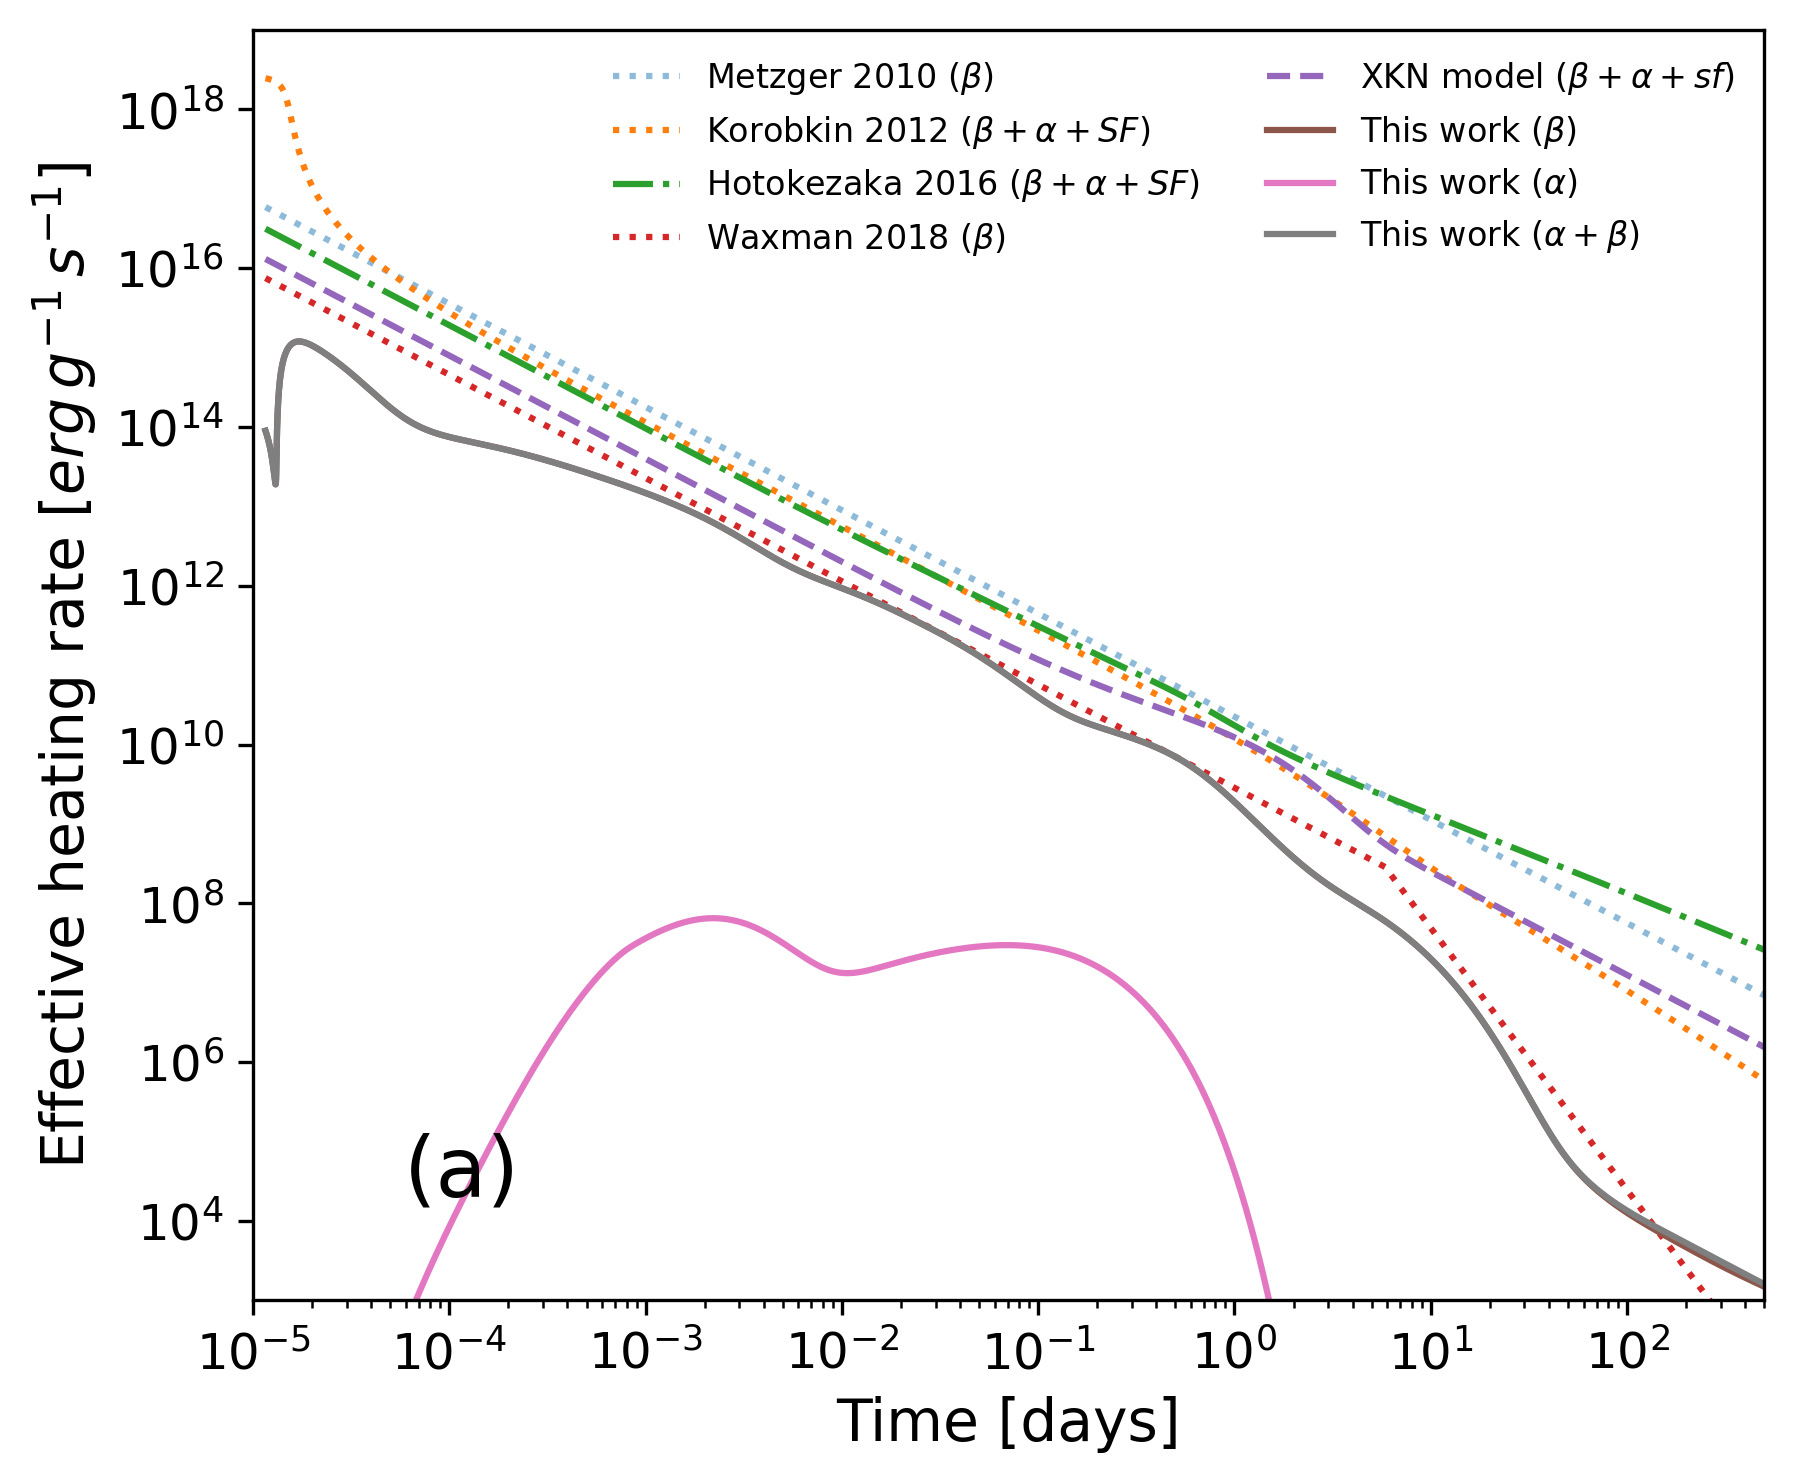

In [5]:
'''Figure 2. Our Heating rate compare to others models'''
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.figure(figsize=(6.5,5.5), dpi=300)

#plt.text(0.1, 0.1, '(b)', fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)
plt.text(0.1, 0.1, '(a)', fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)
plt.plot(time_days,E_metzger,label=r'Metzger 2010 ($\beta$)',linestyle=':',alpha=0.5)
plt.plot(time_days,E_korobkin,label=r'Korobkin 2012 ($\beta+\alpha+SF$)',linestyle=':')
plt.plot(time_days,E_Hoto,label=r'Hotokezaka 2016 ($\beta+\alpha+SF$)',linestyle='-.')
plt.plot(time_days,E_waxman_efectivo,label=r'Waxman 2018 ($\beta$)',linestyle=':')
plt.plot(time_days,E_xkn,label=r'XKN model ($\beta+\alpha+sf$)',linestyle='--')

plt.plot(time_days,e_b_i_ef,label=r'This work ($\beta$)',linestyle='-')
plt.plot(time_days,e_a_i_ef,label=r'This work ($\alpha$)',linestyle='-')
plt.plot(time_days,e_b_i_ef+e_a_i_ef,label=r'This work ($\alpha+\beta$)',linestyle='-')

plt.yscale('log')
plt.xscale('log') 
plt.xlabel('Time [days]')
plt.ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.ylim((1e3,1e19))
plt.xlim((1e-5,5e2))
plt.savefig("figure_epsilon_Approach_I.pdf", bbox_inches="tight")

In [6]:
top = 20 # Define the number of top elements to display

'''Approach I (exponential) Alpha'''
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.figure(figsize=(5,4.5), dpi=300)


plt.plot(time_days,Epsilon_dot_out_exp,label=r'$\dot\epsilon_{Total}$',color='black',linestyle='--')
plt.plot(time_days,Epsilon_beta_out_exp,label=r'$\dot\epsilon_{\beta}$',color='red',linestyle='--')
plt.plot(time_days,Epsilon_alpha_out_exp,label=r'$\dot\epsilon_{\alpha}$',color='green',linestyle='-')
plt.text(0.1, 0.1, '(a)', fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)

relevant_alpha_approachI=[1,2,5,6]

for i in range(top):
    if i+1 in relevant_alpha_approachI:
        data_teo=pd.read_csv(f'Results/relevants_exp/alpha/epsilon_relevant_exp_{i}.csv')
        plt.plot(data_teo['time_days'],data_teo.values[:,1],label=data_teo.columns[1].split(':')[1].split(' ')[0],linestyle=':')

plt.yscale('log')
plt.xscale('log') 
plt.xlabel('Time [days]')
plt.ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.ylim((1e3,1e12))
plt.xlim((0.1,5e2))
plt.savefig("figure_Approach_I_alpha.pdf", bbox_inches="tight")

'''Approach II (out exponential) Alpha'''
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.figure(figsize=(5,4.5), dpi=300)

plt.plot(time_days,Epsilon_dot_out,label=r'$\dot\epsilon_{Total}$',color='black',linestyle='--')
plt.plot(time_days,Epsilon_beta_out,label=r'$\dot\epsilon_{\beta}$',color='red',linestyle='--')
plt.plot(time_days,Epsilon_alpha_out,label=r'$\dot\epsilon_{\alpha}$',color='green')
plt.text(0.1, 0.1, '(b)', fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)

relevant_alpha_approachII=[1,2,7,6,8]#3,4,5,8,13

for i in range(top):
    if i+1 in relevant_alpha_approachII:
        data_teo=pd.read_csv(f'Results/relevants_out_theo/alpha/epsilon_relevant_{i}.csv')
        plt.plot(data_teo['time_days'],data_teo.values[:,1],label=data_teo.columns[1].split(':')[1].split(' ')[0],linestyle=':')

plt.yscale('log')
plt.xscale('log') 
plt.xlabel('Time [days]')
plt.ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.ylim((1e3,1e12))
plt.xlim((0.1,5e2))
plt.savefig("figure_Approach_II_alpha.pdf", bbox_inches="tight")



NameError: name 'Epsilon_dot_out_exp' is not defined

<Figure size 1500x1350 with 0 Axes>

In [ ]:
top = 20 # Define the number of top elements to display

'''Approach I (exponential) Beta'''
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.figure(figsize=(5,4.5), dpi=300)


plt.plot(time_days,Epsilon_dot_out_exp,label=r'$\dot\epsilon_{Total}$',color='black',linestyle='--')
plt.plot(time_days,Epsilon_alpha_out_exp,label=r'$\dot\epsilon_{\alpha}$',color='green',linestyle='--')
plt.plot(time_days,Epsilon_beta_out_exp,label=r'$\dot\epsilon_{\beta}$',color='red',linestyle='-')
plt.text(0.1, 0.1, '(a)', fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)

relevant_beta_approachI=[1,2,3,4]#5,6

for i in range(top):
    if i+1 in relevant_beta_approachI:
        data_teo=pd.read_csv(f'Results/relevants_exp/beta/epsilon_relevant_exp_{i}.csv')
        plt.plot(data_teo['time_days'],data_teo.values[:,1],label=data_teo.columns[1].split(':')[1].split(' ')[0],linestyle=':')

plt.yscale('log')
plt.xscale('log') 
plt.xlabel('Time [days]')
plt.ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.ylim((1e3,1e12))
plt.xlim((0.1,5e2))
plt.savefig("figure_Approach_I_beta.pdf", bbox_inches="tight")

'''Approach II (out exponential) Beta'''
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.figure(figsize=(5,4.5), dpi=300)

plt.plot(time_days,Epsilon_dot_out,label=r'$\dot\epsilon_{Total}$',color='black',linestyle='--')
plt.plot(time_days,Epsilon_alpha_out,label=r'$\dot\epsilon_{\alpha}$',color='green',linestyle='--')
plt.plot(time_days,Epsilon_beta_out,label=r'$\dot\epsilon_{\beta}$',color='red',linestyle='-')
plt.text(0.1, 0.1, '(b)', fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)

relevant_beta_approachII=[1,2,3,6]#4,8

for i in range(top):
    if i+1 in relevant_beta_approachII:
        data_teo=pd.read_csv(f'Results/relevants_out_theo/beta/epsilon_relevant_{i}.csv')
        plt.plot(data_teo['time_days'],data_teo.values[:,1],label=data_teo.columns[1].split(':')[1].split(' ')[0],linestyle=':')

plt.yscale('log')
plt.xscale('log') 
plt.xlabel('Time [days]')
plt.ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.ylim((1e3,1e12))
plt.xlim((0.1,5e2))
plt.savefig("figure_Approach_II_beta.pdf", bbox_inches="tight")

Luminosity

In [ ]:

def dudt_funtion_of_E_t(ta,u,b,tc,E__):
    if ta<=1:
        return (E__[np.searchsorted(time,ta*tc)])/(ta**3)-u*((4/ta) + 3*ta/(4*b))
    elif ta>1:
        return (E__[np.searchsorted(time,ta*tc)])/(ta**3)-(u/ta)*(4+3/(4*b))
 
def solucionar(U_0,tau_n,b,tc,n,E__):
    U_n=np.zeros(n)
    U_n[0]=U_0
    
    h=tau_n[1]-tau_n[0]
    for i in range(len(U_n)):
    
        k1=h*dudt_funtion_of_E_t(tau_n[i],U_n[i],b,tc,E__)
        k2=h*dudt_funtion_of_E_t(tau_n[i]+h/2,U_n[i]+k1/2,b,tc,E__)
        k3=h*dudt_funtion_of_E_t(tau_n[i]+h/2,U_n[i]+k2/2,b,tc,E__)
        k4=h*dudt_funtion_of_E_t(tau_n[i]+h,U_n[i]+k3,b,tc,E__)
        if i!=len(U_n)-1:
            U_n[i+1]=U_n[i]+(1/6)*(k1+2*k2+2*k3+k4)
    return U_n

def generar_graficas(M,k,b,U_0,tau_0,tau_f,n,E_):
    M=M*(1.989*10**30)#kg
    tc=np.sqrt(3*k*M/(4*np.pi*(b*c)**2))
    
    Tau_n=np.linspace(tau_0,tau_f,n)
    Uo=solucionar(U_0,Tau_n,b,tc,n,E_)
    te=tc*Tau_n
    tedias=te*(1/(60*60*24))
    U=((3*M)/(4*np.pi*((b*c)**3)*((tc)**(2))))*Uo
    L=np.zeros(len(U))
    i_tc=np.searchsorted(te,tc)
    L[:i_tc]=((np.pi*((b*c)**2)*c)*(te[:i_tc]**4)/(tc**2))*U[:i_tc]*10**7
    calpha=L[i_tc-1]/E_[np.searchsorted(time,tc)]
    #print(calpha,L[i_tc-1],E_[np.searchsorted(t,tc)])    
    #L[i_tc:]=((np.pi*c*(b*c)**2))*(te[i_tc:]**2)*U[i_tc:]*10**7
    
    spline_interp = interp1d(time, E_, kind='linear', fill_value="extrapolate")
    e_new=spline_interp(te)
    L[i_tc:]=calpha*e_new[i_tc:]
    T=(calpha,L[i_tc],E_[np.searchsorted(time,tc)])  
    #T=0#(c*U/(Sb*4))**(1/4)
    
    
    return [U,L,T,tedias]

In [ ]:
'''Luminosity for alpha and beta approach I'''
top=20

L_tot_I=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,Epsilon_dot_out_exp*1e-4)
U_t,L_t_tot_I,T_t,tedias_t=L_tot_I[0],L_tot_I[1],L_tot_I[2],L_tot_I[3]

L_Beta_I=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,Epsilon_beta_out_exp*1e-4)
U_b,L_b_tot_I,T_b,tedias_b=L_Beta_I[0],L_Beta_I[1],L_Beta_I[2],L_Beta_I[3]

L_Alpha_I=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,Epsilon_alpha_out_exp*1e-4)
U_a,L_a_tot_I,T_a,tedias_a=L_Alpha_I[0],L_Alpha_I[1],L_Alpha_I[2],L_Alpha_I[3]

L_b_I=[]
names_b_I=[]
L_a_I=[]
names_a_I=[]
relevant_beta_approachI=[1,4]
relevant_alpha_approachI=[1,2]

for i in range(top):
    if i+1 in relevant_beta_approachI:
        data_teo=pd.read_csv(f'Results/relevants_exp/beta/epsilon_relevant_exp_{i}.csv') 
        U_b,L_b,T_b,tedias_b=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,data_teo.values[:,1]*1e-4)
        L_b_I.append(L_b)
        names_b_I.append(data_teo.columns[1].split(':')[1].split(' ')[0])
    if i+1 in relevant_alpha_approachI:
        data_teo=pd.read_csv(f'Results/relevants_exp/alpha/epsilon_relevant_exp_{i}.csv')
        U_a,L_a,T_a,tedias_a=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,data_teo.values[:,1]*1e-4)
        L_a_I.append(L_a)
        names_a_I.append(data_teo.columns[1].split(':')[1].split(' ')[0])


In [ ]:
x=np.log(tedias_t[np.searchsorted(tedias_t,np.exp(np.linspace(np.log(3),np.log(50),10)),side='left')-1])
y=np.log(L_t_tot_I[np.searchsorted(tedias_t,np.exp(np.linspace(np.log(3),np.log(50),10)),side='left')-1])
[m,b]=curve_fit(lambda xh,m,b:m*xh+b,x,y)[0]
fitx=np.exp(np.linspace(0,np.log(500),10))
fity=np.exp(m*np.log(fitx)+b)

In [ ]:
'''Figures Luminosity Approach I'''

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
plt.figure(figsize=(5,4.5),dpi=300)
plt.plot(tedias_t,L_t_tot_I,label=r'total Luminosity',color='black')
plt.plot(tedias_b,L_b_tot_I,label=r'Luminosity $\beta$',color='red')
plt.plot(tedias_a,L_a_tot_I,label=r'Luminosity $\alpha$',color='green')
plt.plot(fitx,fity,label=f'Fit total: ',linestyle='--',color='black')
plt.text(0.05, 0.2, '(a)', fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)

for i in range(len(L_a_I)):
    plt.plot(tedias_a,L_a_I[i],linestyle=':',label=names_a_I[i]+r' ($\alpha$)')
for i in range(len(L_b_I)):
    plt.plot(tedias_b,L_b_I[i],linestyle=':',label=names_b_I[i]+r' ($\beta$)')
plt.yscale('log')
plt.ylim((1e37,1e42))
plt.xlim((1,500))
plt.xscale('log')
plt.xlabel('Time [days]')
plt.ylabel(r'Luminosity $[erg\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.savefig("figure_Approach_I_Luminosity.pdf", bbox_inches="tight")


In [ ]:
'''Luminosity for alpha and beta approach II'''
L_tot_II=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,Epsilon_dot_out*1e-4)
U_t,L_t_tot_II,T_t,tedias_t=L_tot_II[0],L_tot_II[1],L_tot_II[2],L_tot_II[3]

L_Beta_II=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,Epsilon_beta_out*1e-4)
U_b,L_b_tot_II,T_b,tedias_b=L_Beta_II[0],L_Beta_II[1],L_Beta_II[2],L_Beta_II[3]

L_Alpha_II=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,Epsilon_alpha_out*1e-4)
U_a,L_a_tot_II,T_a,tedias_a=L_Alpha_II[0],L_Alpha_II[1],L_Alpha_II[2],L_Alpha_II[3]

top=20

L_b_II=[]
names_b_II=[]
L_a_II=[]
names_a_II=[]
relevant_alpha_approachII=[1,2,6,7]
relevant_beta_approachII=[2]
for i in range(top):
    if i+1 in relevant_beta_approachII:
        data_teo=pd.read_csv(f'Results/relevants_out_theo/beta/epsilon_relevant_{i}.csv') 
        U_b,L_b,T_b,tedias_b=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,data_teo.values[:,1]*1e-4)
        L_b_II.append(L_b)
        names_b_II.append(data_teo.columns[1].split(':')[1].split(' ')[0])
    if i+1 in relevant_alpha_approachII:
        data_teo=pd.read_csv(f'Results/relevants_out_theo/alpha/epsilon_relevant_{i}.csv')
        U_a,L_a,T_a,tedias_a=generar_graficas(0.05,0.02,0.15,10**10,0.001,85,100000,data_teo.values[:,1]*1e-4)
        L_a_II.append(L_a)
        names_a_II.append(data_teo.columns[1].split(':')[1].split(' ')[0])

In [ ]:
x=np.log(tedias_t[np.searchsorted(tedias_t,np.exp(np.linspace(np.log(3),np.log(100),10)),side='left')-1])
y=np.log(L_t_tot_II[np.searchsorted(tedias_t,np.exp(np.linspace(np.log(3),np.log(100),10)),side='left')-1])
[m,b]=curve_fit(lambda xh,m,b:m*xh+b,x,y)[0]
fitx=np.exp(np.linspace(0,np.log(500),10))
fity=np.exp(m*np.log(fitx)+b)

In [ ]:

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
plt.figure(figsize=(5,4.5),dpi=300)
plt.plot(tedias_t,L_t_tot_II,label=r'total Luminosity',color='black')
plt.plot(tedias_b,L_b_tot_II,label=r'Luminosity $\beta$',color='red')
plt.plot(tedias_a,L_a_tot_II,label=r'Luminosity $\alpha$',color='green')
plt.text(0.05, 0.2, '(b)', fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)
plt.plot(fitx,fity,label=f'Fit total: ',linestyle='--',color='black')
#plt.plot(np.zeros(2)+5.6,[1e36,1e42],color='black',linestyle='--',label='5.6 days')

for i in range(len(L_a_II)):
    plt.plot(tedias_a,L_a_II[i],linestyle=':',label=names_a_II[i]+r' ($\alpha$)')
for i in range(len(L_b_II)):
    plt.plot(tedias_b,L_b_II[i],linestyle=':',label=names_b_II[i]+r' ($\beta$)')
plt.yscale('log')
plt.ylim((1e37,1e42))
plt.xlim((1,500))
plt.xscale('log')
plt.xlabel('Time [days]')
plt.ylabel(r'Luminosity $[erg\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.savefig("figure_Approach_II_Luminosity.pdf", bbox_inches="tight")
